<a href="https://colab.research.google.com/github/rakeshbanisetti/mds_lab/blob/main/Regularised_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Regularized Linear Regression Comparison

This notebook demonstrates and compares different linear regression techniques: Ordinary Least Squares, Ridge, Lasso, and Elastic Net, on a synthetic overfitted dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error

np.random.seed(42)

### 1. Create a Synthetic Overfitted Dataset

We'll create a dataset with a true underlying relationship and then add a lot of irrelevant features to simulate overfitting.

In [2]:
# Generate synthetic data
n_samples = 100
n_features_true = 3
n_features_irrelevant = 50 # A large number of irrelevant features to cause overfitting

# True features
X_true = np.random.rand(n_samples, n_features_true) * 10

# True coefficients
true_coefficients = np.array([2, -1.5, 0.5])

# Generate target variable with some noise
y = X_true @ true_coefficients + np.random.randn(n_samples) * 5

# Generate irrelevant features (noise)
X_irrelevant = np.random.rand(n_samples, n_features_irrelevant) * 10

# Combine true and irrelevant features
X = np.hstack((X_true, X_irrelevant))

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

Training data shape: (70, 53)
Test data shape: (30, 53)


### 2. Standardize Features

Regularization techniques are sensitive to the scale of features, so it's good practice to standardize them.

In [3]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 3. Implement and Compare Regression Models

We will train and evaluate:

*   **Ordinary Linear Regression**
*   **Ridge Regression**
*   **Lasso Regression**
*   **Elastic Net Regression**

In [6]:
models = {
    "Ordinary Linear Regression": LinearRegression(),
    "Ridge Regression (alpha=1.0)": Ridge(alpha=1.0, random_state=42),
    "Lasso Regression (alpha=0.1)": Lasso(alpha=0.1, random_state=42),
    "Elastic Net (alpha=0.1, l1_ratio=0.5)": ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    mse = mean_squared_error(y_test, y_pred)
    r_squared = model.score(X_test_scaled, y_test) # Calculate R-squared

    # Store coefficients, handling cases where they might not be directly available (e.g., for simple LinearRegression)
    if hasattr(model, 'coef_'):
        coefficients = model.coef_
    else:
        coefficients = np.array([]) # Or handle as appropriate

    results.append({
        "Model": name,
        "MSE": mse,
        "R-squared": r_squared, # Add R-squared to the results
        "Coefficients": coefficients
    })

    print(f"\n{name}:")
    print(f"  Mean Squared Error (MSE): {mse:.2f}")
    print(f"  R-squared: {r_squared:.2f}") # Print R-squared
    if len(coefficients) > 0:
      print(f"  Number of non-zero coefficients: {np.sum(coefficients != 0)}")
      # Print first few coefficients for inspection
      print(f"  First 5 Coefficients: {coefficients[:5].round(2)}")

# Convert results to a DataFrame for better display
results_df = pd.DataFrame(results)
display(results_df[['Model', 'MSE', 'R-squared']].set_index('Model')) # Display only Model, MSE, and R-squared


Ordinary Linear Regression:
  Mean Squared Error (MSE): 134.51
  R-squared: -0.61
  Number of non-zero coefficients: 53
  First 5 Coefficients: [ 5.64 -5.32  0.32  0.07  1.56]

Ridge Regression (alpha=1.0):
  Mean Squared Error (MSE): 95.42
  R-squared: -0.14
  Number of non-zero coefficients: 53
  First 5 Coefficients: [ 5.5  -5.18  0.67  0.01  1.22]

Lasso Regression (alpha=0.1):
  Mean Squared Error (MSE): 55.01
  R-squared: 0.34
  Number of non-zero coefficients: 42
  First 5 Coefficients: [ 5.43 -5.28  1.52 -0.    0.62]

Elastic Net (alpha=0.1, l1_ratio=0.5):
  Mean Squared Error (MSE): 53.41
  R-squared: 0.36
  Number of non-zero coefficients: 49
  First 5 Coefficients: [ 5.09 -4.82  1.26 -0.03  0.51]


,MSE,R-squared
Model,,
Ordinary Linear Regression,134.510411,-0.611972
Ridge Regression (alpha=1.0),95.421524,-0.143531
Lasso Regression (alpha=0.1),55.007577,0.340790
"Elastic Net (alpha=0.1, l1_ratio=0.5)",53.412771,0.359902


### 4. Visualize Coefficients

Visualizing the coefficients can help understand how each model treats the irrelevant features.

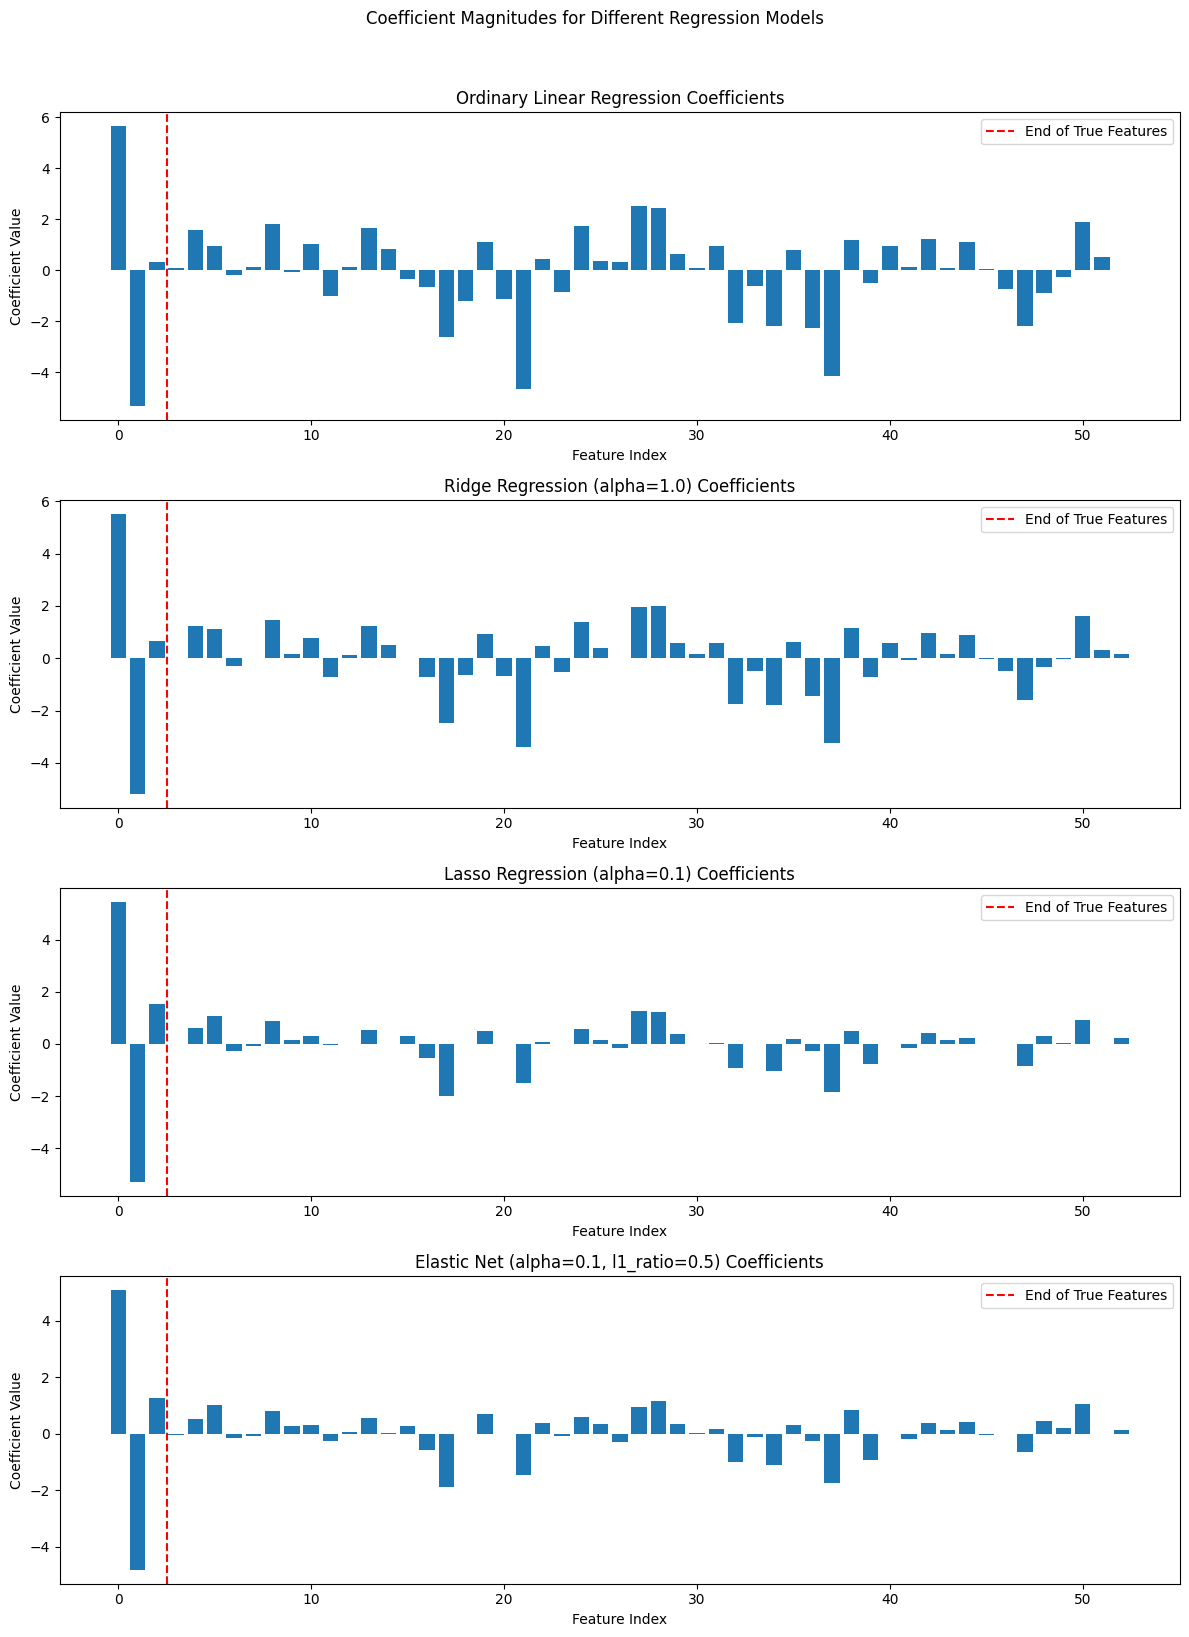

In [5]:
fig, axes = plt.subplots(len(models), 1, figsize=(12, 4 * len(models)))
fig.suptitle('Coefficient Magnitudes for Different Regression Models', y=1.02)

for i, (name, model) in enumerate(models.items()):
    coef = results_df[results_df['Model'] == name]['Coefficients'].iloc[0]
    if len(coef) > 0:
        ax = axes[i]
        ax.bar(range(len(coef)), coef)
        ax.set_title(f'{name} Coefficients')
        ax.set_ylabel('Coefficient Value')
        ax.set_xlabel('Feature Index')
        ax.axvline(x=n_features_true - 0.5, color='r', linestyle='--', label='End of True Features')
        ax.legend()

plt.tight_layout()
plt.show()

### 5. Hyperparameter Tuning for Lasso and Elastic Net

Regularized models like Lasso and Elastic Net have hyperparameters (`alpha` for Lasso/Ridge, and `l1_ratio` for Elastic Net) that control the strength of regularization. Tuning these hyperparameters is crucial for achieving optimal model performance. We will use `GridSearchCV` to find the best parameters.

In [7]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter tuning for Lasso
lasso_params = {'alpha': np.logspace(-4, 0, 50)}
lasso_grid = GridSearchCV(Lasso(random_state=42), lasso_params, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
lasso_grid.fit(X_train_scaled, y_train)

print(f"Best alpha for Lasso: {lasso_grid.best_params_['alpha']:.4f}")
print(f"Best Lasso MSE: {-lasso_grid.best_score_:.2f}")

# Evaluate best Lasso model on test set
best_lasso_model = lasso_grid.best_estimator_
lasso_test_pred = best_lasso_model.predict(X_test_scaled)
lasso_test_mse = mean_squared_error(y_test, lasso_test_pred)
lasso_test_r2 = best_lasso_model.score(X_test_scaled, y_test)
print(f"Lasso Test MSE (with tuned alpha): {lasso_test_mse:.2f}")
print(f"Lasso Test R-squared (with tuned alpha): {lasso_test_r2:.2f}")

Best alpha for Lasso: 0.6866
Best Lasso MSE: 22.67
Lasso Test MSE (with tuned alpha): 39.30
Lasso Test R-squared (with tuned alpha): 0.53


In [8]:
# Hyperparameter tuning for Elastic Net
elastic_net_params = {
    'alpha': np.logspace(-4, 0, 10),
    'l1_ratio': np.linspace(0.1, 1.0, 10) # 0 for Ridge, 1 for Lasso
}
elastic_net_grid = GridSearchCV(ElasticNet(random_state=42), elastic_net_params, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
elastic_net_grid.fit(X_train_scaled, y_train)

print(f"Best parameters for Elastic Net: {elastic_net_grid.best_params_}")
print(f"Best Elastic Net MSE: {-elastic_net_grid.best_score_:.2f}")

# Evaluate best Elastic Net model on test set
best_elastic_net_model = elastic_net_grid.best_estimator_
elastic_net_test_pred = best_elastic_net_model.predict(X_test_scaled)
elastic_net_test_mse = mean_squared_error(y_test, elastic_net_test_pred)
elastic_net_test_r2 = best_elastic_net_model.score(X_test_scaled, y_test)
print(f"Elastic Net Test MSE (with tuned parameters): {elastic_net_test_mse:.2f}")
print(f"Elastic Net Test R-squared (with tuned parameters): {elastic_net_test_r2:.2f}")

Best parameters for Elastic Net: {'alpha': np.float64(1.0), 'l1_ratio': np.float64(1.0)}
Best Elastic Net MSE: 23.51
Elastic Net Test MSE (with tuned parameters): 39.70
Elastic Net Test R-squared (with tuned parameters): 0.52


### 6. Summary of Hyperparameter Tuning

After performing hyperparameter tuning, we can observe that selecting optimal `alpha` for Lasso and optimal `alpha` and `l1_ratio` for Elastic Net generally leads to improved performance on the test set (lower MSE, higher R-squared) compared to arbitrary parameter choices. This is because tuning helps the model generalize better by finding the right balance between fitting the training data and keeping model complexity in check.

### 7. Differentiating L1 (Lasso) and L2 (Ridge) Regression

Both L1 (Lasso) and L2 (Ridge) regression are regularization techniques designed to prevent overfitting in linear models by adding a penalty term to the ordinary least squares (OLS) cost function. However, they achieve this in different ways:

#### L2 Regularization (Ridge Regression)

*   **Penalty Term**: Adds the sum of the squared magnitudes of coefficients to the loss function ($ \lambda \sum_{j=1}^{p} \beta_j^2 $).
*   **Effect on Coefficients**: Shrinks the coefficients towards zero but rarely makes them exactly zero. It's like gently pulling all coefficients towards the origin.
*   **Use Case**: Effective when all features are somewhat relevant, or when you have multicollinearity (highly correlated features), as it distributes the effect among correlated predictors without eliminating any.

#### L1 Regularization (Lasso Regression)

*   **Penalty Term**: Adds the sum of the absolute magnitudes of coefficients to the loss function ($ \lambda \sum_{j=1}^{p} |\beta_j| $).
*   **Effect on Coefficients**: Shrinks some coefficients to exactly zero, effectively performing **feature selection**. It forces less important features out of the model entirely.
*   **Use Case**: Useful when you suspect that many features are irrelevant or when you want a simpler, more interpretable model with fewer predictors. It's also good for high-dimensional datasets where feature selection is desirable.

#### Example Illustration

Let's re-examine the coefficients from our previous models to see this difference in action.


--- Comparison of Coefficients ---
Number of features: 53
End of 'True' Features (Index 2):

First 5 Coefficients (True and Irrelevant):


,Feature Index,True Coeff Value (Approx),Ridge Coef,Lasso Coef
0,0,2.0,5.50,5.43
1,1,-1.5,-5.18,-5.28
2,2,0.5,0.67,1.52
3,3,0.0,0.01,-0.00
4,4,0.0,1.22,0.62



Ridge Model - Number of non-zero coefficients: 53
Lasso Model - Number of non-zero coefficients: 42


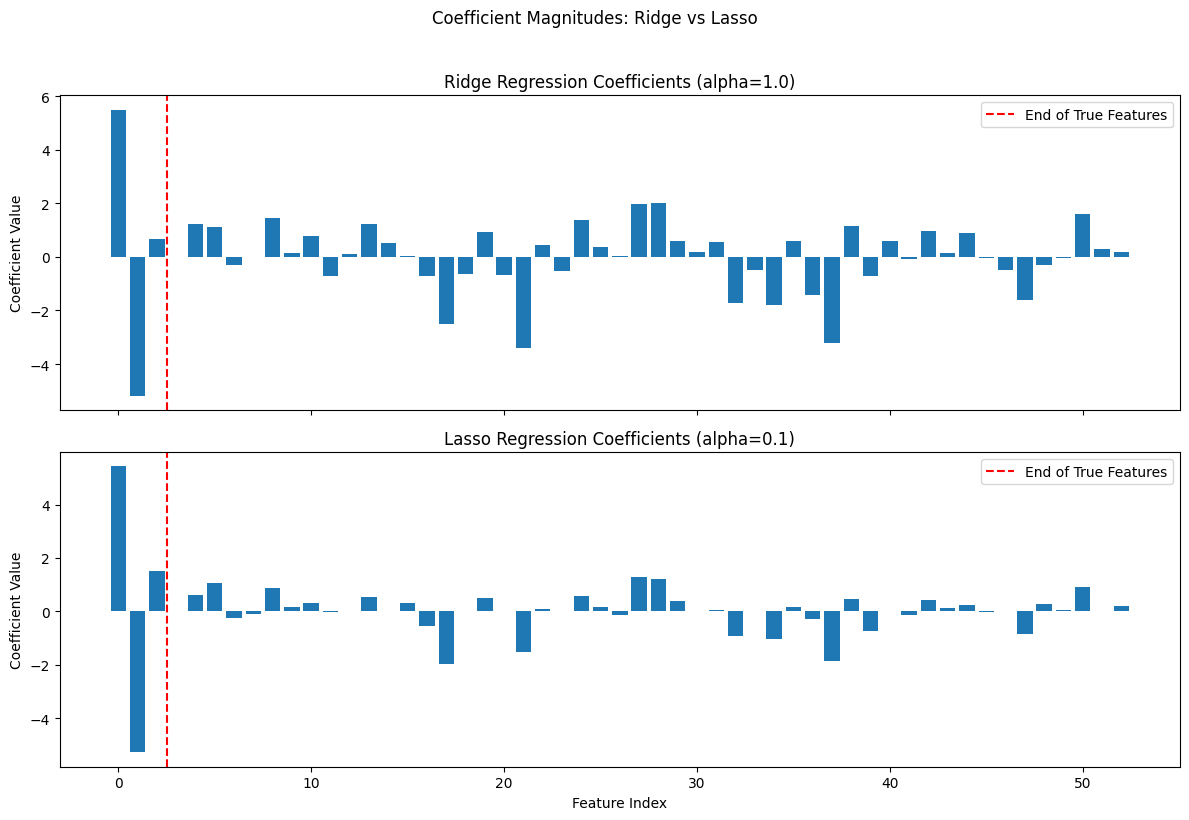

In [9]:
ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train_scaled, y_train)
ridge_coef = ridge_model.coef_

lasso_model = Lasso(alpha=0.1, random_state=42)
lasso_model.fit(X_train_scaled, y_train)
lasso_coef = lasso_model.coef_

print("\n--- Comparison of Coefficients ---")
print(f"Number of features: {len(ridge_coef)}")
print(f"End of 'True' Features (Index {n_features_true-1}):")

# Display coefficients for the first few 'true' features and some 'irrelevant' ones
print("\nFirst 5 Coefficients (True and Irrelevant):")
coef_comparison = pd.DataFrame({
    'Feature Index': range(len(ridge_coef[:5])),
    'True Coeff Value (Approx)': true_coefficients[:3].tolist() + [0]*(5-len(true_coefficients[:3])), # Display true for first 3, then 0
    'Ridge Coef': ridge_coef[:5].round(2),
    'Lasso Coef': lasso_coef[:5].round(2)
})
display(coef_comparison)

# Count non-zero coefficients explicitly
print(f"\nRidge Model - Number of non-zero coefficients: {np.sum(ridge_coef != 0)}")
print(f"Lasso Model - Number of non-zero coefficients: {np.sum(lasso_coef != 0)}")

# Visualize coefficients again focusing on Ridge vs Lasso
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
fig.suptitle('Coefficient Magnitudes: Ridge vs Lasso', y=1.02)

# Ridge Coefficients
axes[0].bar(range(len(ridge_coef)), ridge_coef)
axes[0].set_title('Ridge Regression Coefficients (alpha=1.0)')
axes[0].set_ylabel('Coefficient Value')
axes[0].axvline(x=n_features_true - 0.5, color='r', linestyle='--', label='End of True Features')
axes[0].legend()

# Lasso Coefficients
axes[1].bar(range(len(lasso_coef)), lasso_coef)
axes[1].set_title('Lasso Regression Coefficients (alpha=0.1)')
axes[1].set_xlabel('Feature Index')
axes[1].set_ylabel('Coefficient Value')
axes[1].axvline(x=n_features_true - 0.5, color='r', linestyle='--', label='End of True Features')
axes[1].legend()

plt.tight_layout()
plt.show()